# Section 3: Logistic Growth Model

## Background
The **logistic growth model represents how populations change over time when resources are limited**. The logistic model incorporates a carrying capacity—the maximum population size a specific environment can sustainably support.

**Key Concepts**
* **Carrying Capacity ($K$)**: A ceiling that limits population growth due to limited resources (food, space, water, etc.).
* **Intrinsic Growth Rate ($r$)**: The rate at which a population would grow if there were unlimited resources.
* **S-Shaped Curve**: The logistic growth model plots as an S-shaped curve. Growth is initially exponential, then slows as it approaches the carrying capacity.



## Equation of Logistic Growth

**Differential equation of logistic growth:**
$$ \frac{dP}{dt} = rP\left(1 - \frac{P}{K}\right) $$

**Iterative Form:**
$$ P(t_{i+1}) = P(t_i) + rP(t_i)\left(1 - \frac{P(t_i)}{K}\right) \Delta t $$

**Explicit solution:**
$$ P(t) = \frac{K}{1 + \left(\frac{K - P_0}{P_0} \right) e^{-rt}} $$

Where:
* $P(t_i)$ is the population at time $t_i$
* $P_0$ is the initial population
* $r$ is the growth rate
* $K$ is the carrying capacity
* $t$ is time, $\Delta t$ is the time step 

## Discussion: Railway Construction

Consider historical data showing French vs. English railway construction. 

**Topics for discussion**
* Why do you think that the French railway construction follows logistic growth but the English does not? 
* How would you explain **carrying capacity** in the context of railroad construction? 
* What may affect the carrying capacity for railways? Is the capacity constant or dynamic? 

## Closer Look at the Equation & Equilibrium

Let’s explore the equation: try to figure out how the carrying capacity affects population growth. Try different combinations of $P$ and $K$. What are the equilibrium solutions where there is no population growth? 

To find equilibrium solutions, we set the derivative to zero:
$$ 0 = rP \left(1 - \frac{P}{K}\right) $$

This equation is satisfied when either:
1. The population is zero: $P = 0$
2. The growth rate is zero: $r = 0$
3. The population size equals the carrying capacity: $P = K$

## History


* **Pierre Verhulst**: A Belgian mathematician who first proposed the logistic model in the 1830s and 1840s. His model sought to refine the exponential population growth model of Malthus.
* Verhulst got inspiration from the concept of intraspecific competition—the idea that as populations get larger, individuals compete more intensely for limited resources.
* This equation was published after Verhulst had read Thomas Malthus' *An Essay on the Principle of Population*.

## Applications
The logistic growth model has extensive applications:
* **Biology**: Used extensively in modeling animal, plant, and bacterial population growth.
* **Epidemiology and medicine**: Helps analyze how diseases spread within a population or tumor growth.
* **Economics**: Modeling market adoption of new products or technologies—a diffusion of innovation.
* **Linguistics**: An innovation that is at first marginal begins to spread more quickly with time, and then more slowly as it becomes more universally adopted.
* **Statistics and machine learning**: Logistic functions are often used in artificial neural networks to introduce nonlinearity in the model—but it is mostly for the shape.

## Exercises

**Task 1 & 2 Overview**
1. Numerically solve the logistic growth equation and plot: Population size vs. time, Population increase vs. time, Per capita growth rate vs. population size, Population increase vs. population size.
2. Adjust the appearance of the plot: 
    * Add a plot title and axis labels 
    * Change line thickness and appearance 
    * Experiment with other changes 
3. Experiment with model parameters:
    * Try to increase the initial population over the capacity of the environment 

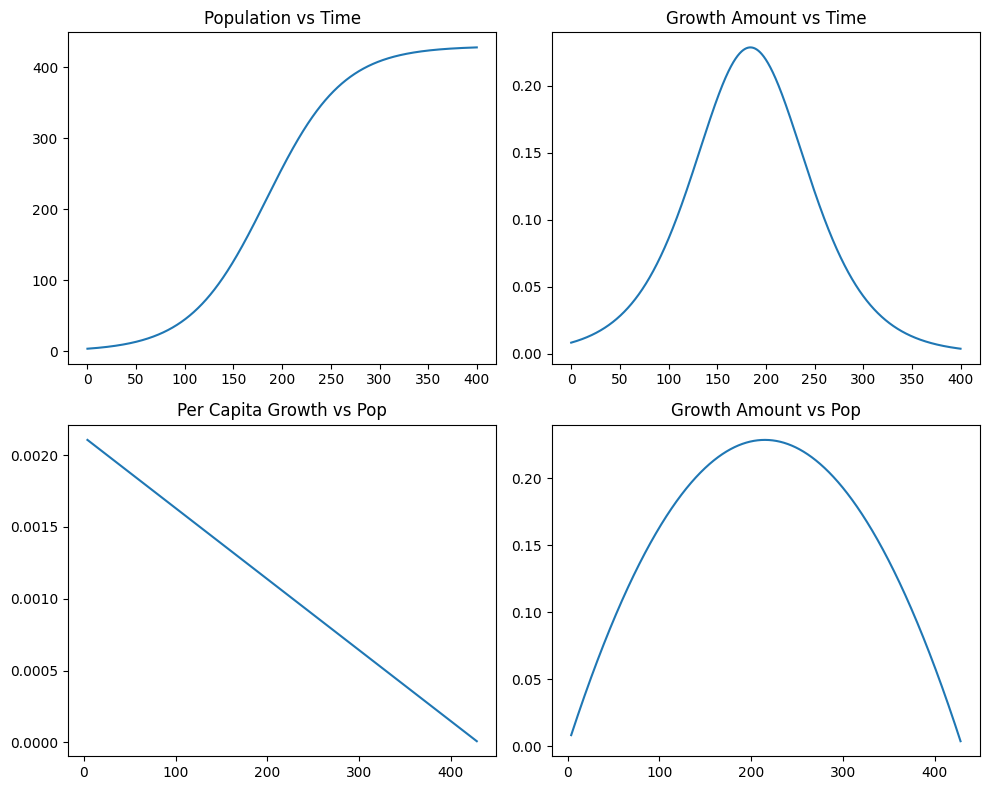

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and Time
P0, r, K = 3.9, 0.0255, 430
t = np.arange(0, 400, 1/12)

# Vectorized Logistic Growth (Analytical Solution)
# P(t) = K / (1 + ((K - P0) / P0) * exp(-rt))
P = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
P_diff = r * P * (1 - P / K) * (1/12)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
plots = [
    (t, P, "Population vs Time"),
    (t, P_diff, "Growth Amount vs Time"),
    (P, P_diff / P, "Per Capita Growth vs Pop"),
    (P, P_diff, "Growth Amount vs Pop")
]

for ax, (x, y, title) in zip(axs.flat, plots):
    ax.plot(x, y)
    ax.set_title(title)

plt.tight_layout()
plt.show()

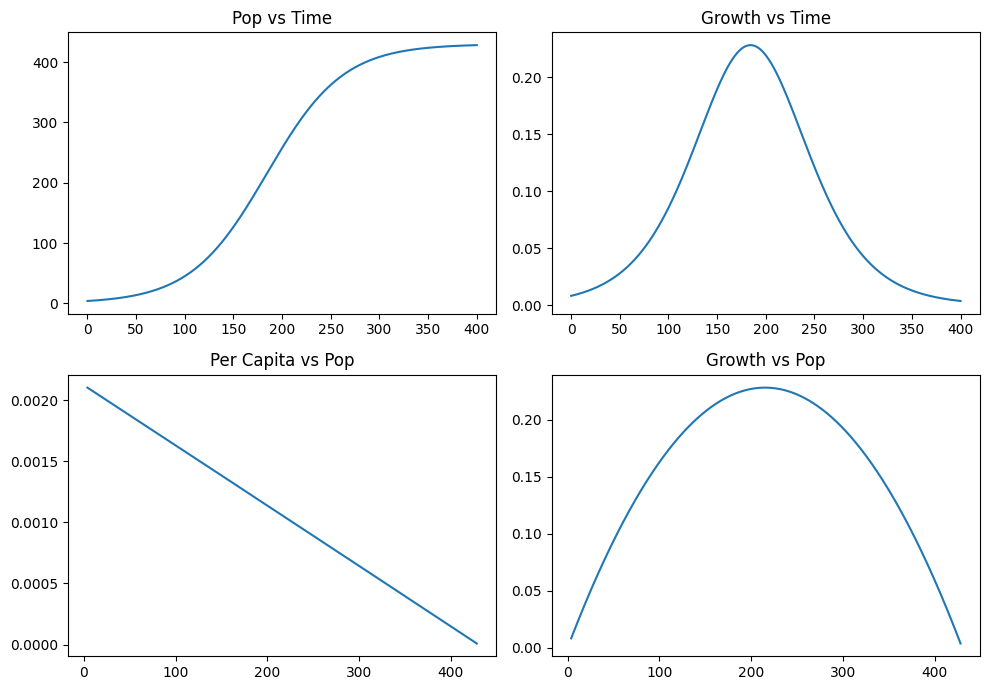

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Params & Time
P0, r, K, dt = 3.9, 0.0255, 430, 1/12
t = np.arange(0, 400 + dt, dt)
P = np.zeros(len(t))
P[0] = P0

# Iterative solution
for i in range(len(t) - 1):
    P[i+1] = P[i] + r * P[i] * (1 - P[i] / K) * dt

# Derived Data
P_diff = np.concatenate([[np.nan], np.diff(P)])
plots = [(t, P, "Pop vs Time"), (t, P_diff, "Growth vs Time"),  (P, P_diff/P, "Per Capita vs Pop"), (P, P_diff, "Growth vs Pop")]

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
for ax, (x, y, title) in zip(axs.flat, plots):
    ax.plot(x, y)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Task 3: USA Population Modeling

4. Model the population of the USA and compare it with real data.

*For the population model of the USA, set the step size to 1 month, the initial population size to 5.2 million in 1790, the growth rate to 0.0237, and the capacity of the environment to 460 million.*

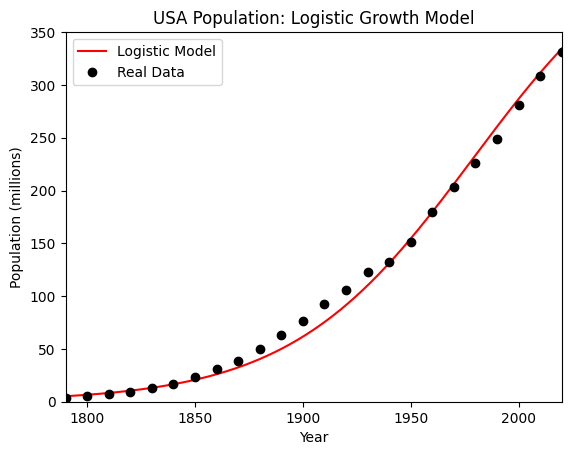

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r, P0, K, start_year = 0.0237, 5.2, 460, 1790
t_usa = np.arange(0, 240, 10)
P_usa = np.array([3.9, 5.3, 7.2, 9.6, 12.9, 17.1, 23.2, 31.4, 38.6, 50.2, 63.0, 76.2, 92.2, 106.0, 123.2, 132.2, 151.3, 179.3, 203.3, 226.5, 248.7, 281.4, 308.7, 331.4])

dt = 1/12
t_num = np.arange(0, 230 + dt, dt)
P_num = np.zeros(len(t_num))
P_num[0] = P0

for i in range(len(t_num) - 1):
    P_num[i+1] = P_num[i] + r * P_num[i] * (1 - P_num[i] / K) * dt

# Plotting
plt.plot(t_num + start_year, P_num, 'r-', label='Logistic Model')
plt.plot(t_usa + start_year, P_usa, 'ko', label='Real Data')
plt.axis([1790, 2020, 0, 350])
plt.legend(); plt.title("USA Population: Logistic Growth Model")
plt.xlabel("Year"); plt.ylabel("Population (millions)")
plt.show()

## Task 4: Visualizing the "Flow" with a Vector Field

So far, we have looked at specific solutions to the logistic growth equation by setting a starting population ($P_0$) and calculating step-by-step. But what if we want to see **every possible future** at a single glance?

Enter the **Vector Field** (or Direction Field). 

Because our differential equation $\frac{dP}{dt} = rP\left(1 - \frac{P}{K}\right)$ tells us the exact slope (growth rate) for *any* given population size, we can plot a grid of small arrows. 
* The arrow points in the direction the population will move.
* The color of the arrow shows how fast it is moving.

By dropping a starting population anywhere on this grid, it will naturally follow the "current" of the arrows.

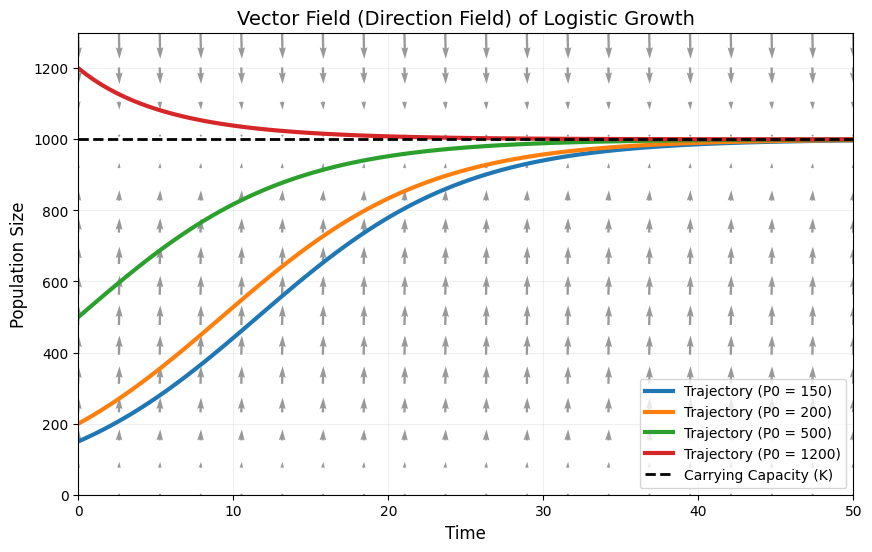

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Base Parameters
r = 0.15         # Intrinsic growth rate
K = 1000         # Carrying capacity
P0_list = [150, 200, 500, 1200] 

# 1. Create a grid of Time (t) and Population (P) values
t_vals = np.linspace(0, 50, 20)
P_vals = np.linspace(0, 1600, 20)
T, P = np.meshgrid(t_vals, P_vals)

# 2. Calculate the direction of the "flow" at each point on the grid
# U is the change in time (which moves steadily forward, so we use 1)
# V is the change in population (dP/dt), calculated using the logistic equation
U = np.ones_like(T)
V = r * P * (1 - P / K)

# We will color the arrows based on how fast the population is changing
growth_speed = np.abs(V)

# 3. Plot the vector field
plt.figure(figsize=(10, 6))
# 'coolwarm' goes from blue (low) to red (high)
Q = plt.quiver(T, P, U, V, color='black', pivot='mid', alpha=0.4)

# 4. Overlay a few specific population trajectories to see how they follow the arrows
t_line = np.linspace(0, 50, 100)
for P0 in P0_list: 
    # Using the analytical solution formula
    P_line = K / (1 + ((K - P0) / P0) * np.exp(-r * t_line))
    plt.plot(t_line, P_line, linewidth=3, label=f'Trajectory (P0 = {P0})')

# 5. Formatting the plot
plt.axhline(K, color='black', linestyle='--', linewidth=2, label='Carrying Capacity (K)')
plt.title("Vector Field (Direction Field) of Logistic Growth", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Population Size", fontsize=12)
plt.xlim(0, 50)
plt.ylim(0, 1300)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.show()

### 💡 What is the Vector Field telling us?

1. **The Magnet (Stable Equilibrium):** Notice how all the arrows pointing from below $K$ are angled upwards, and all the arrows above $K$ are angled downwards. The carrying capacity acts like a magnet, pulling all population trajectories towards it. In mathematics, this is called a **stable equilibrium**.
2. **The Floor (Unstable Equilibrium):** Look at the arrows right along the bottom where $P = 0$. If you are exactly at zero, you stay at zero. But if you get even slightly above zero, the arrows immediately pull you up and away. This is called an **unstable equilibrium**.
3. **The Speed Limit:** The arrows are brightest (yellow/green) right in the middle, around $P = 500$ (which is exactly half of the carrying capacity, $\frac{K}{2}$). This visually confirms that populations grow fastest when they are exactly halfway to their carrying capacity.

## Task 5: Harvesting and Sustainability (Exploration)

What happens when a population is being hunted, fished, or harvested? We can modify the logistic growth equation to include a constant harvesting rate, $H$ (number of individuals removed per unit of time). 

The new differential equation becomes:
$$\frac{dP}{dt} = rP\left(1 - \frac{P}{K}\right) - H$$

If the harvesting rate $H$ is too high, the population will crash and eventually go extinct. If it is balanced, the population will reach a new, lower equilibrium.

**Your Task:**
Run the code block below. Then, experiment with the harvesting rate $H$ and the initial population $P_0$ to see how the population responds.

/var/folders/0z/fgrbcw0d6yq7_jd5ndfl0gr00000gn/T/ipykernel_34580/1538591067.py:42: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  P_line = odeint(logistic_harvest, P0, t_line).flatten()


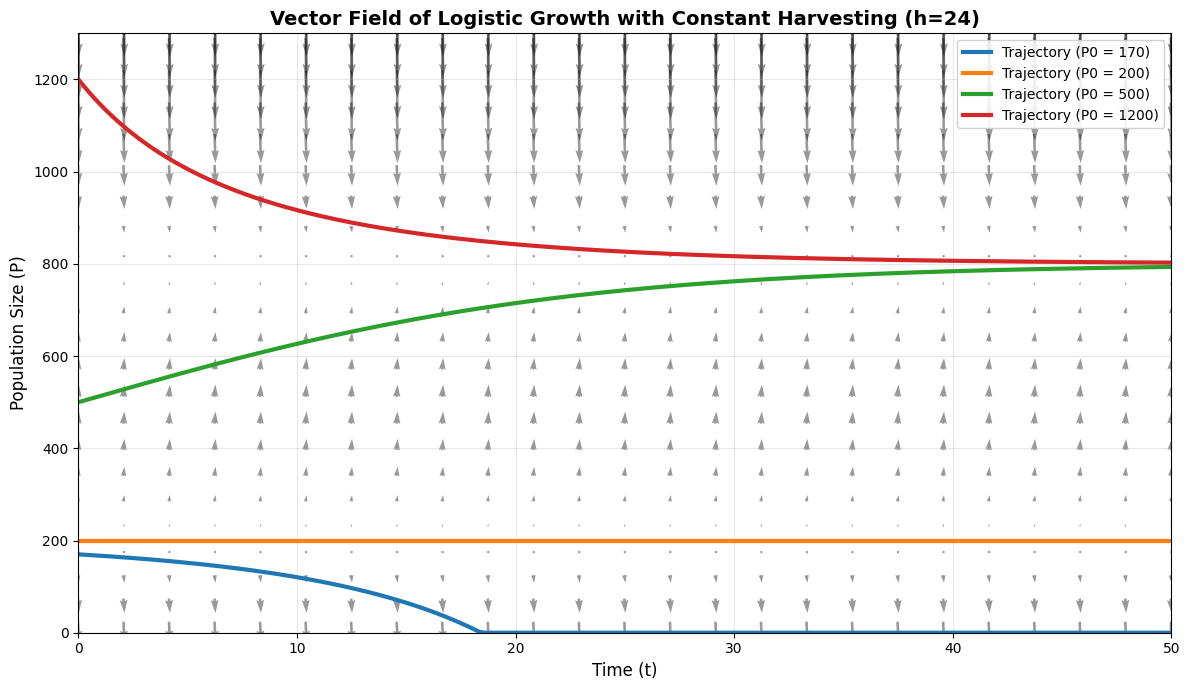

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. Base Parameters
r = 0.15         # Intrinsic growth rate
K = 1000         # Carrying capacity
h = 24           # Constant harvesting rate (Set to 24 to get clean equilibria)

# Initial populations for our "rafts" (trajectories)
# We deliberately set one exactly on the unstable equilibrium (200)
P0_list = [170, 200, 500, 1200] 

# Calculate exact equilibrium points to draw on the plot
discriminant = np.sqrt(r**2 - 4*r*h/K)
P_high = (r + discriminant) / (2*r/K)  # Stable (800)
P_low = (r - discriminant) / (2*r/K)   # Unstable (200)

# 2. Set up the grid for the Vector Field (Arrows)
t_vals = np.linspace(0, 50, 25)
P_vals = np.linspace(0, 1400, 25)
T, P = np.meshgrid(t_vals, P_vals)

# Calculate the direction of the "flow" at each point
U = np.ones_like(T)
V = r * P * (1 - P / K) - h  
growth_speed = np.abs(V)

# 3. Plotting the Vector Field
plt.figure(figsize=(12, 7))
Q = plt.quiver(T, P, U, V, color='black', pivot='mid', alpha=0.4)

# 4. Define the differential equation for the numerical solver
def logistic_harvest(P, t):
    return r * P * (1 - P / K) - h

# 5. Overlay the population trajectories
t_line = np.linspace(0, 50, 200)

for P0 in P0_list:
    # Use scipy's numerical solver to find the trajectory
    P_line = odeint(logistic_harvest, P0, t_line).flatten()
    
    # Find exactly where the population crashes to 0 or below
    extinction_indices = np.where(P_line <= 0)[0]
    
    if len(extinction_indices) > 0:
        # Get the first moment of extinction and set everything after it to strictly 0
        first_zero = extinction_indices[0]
        P_line[first_zero:] = 0
    plt.plot(t_line, P_line, linewidth=3, label=f'Trajectory (P0 = {P0})')


plt.title("Vector Field of Logistic Growth with Constant Harvesting (h=24)", fontsize=14, fontweight='bold')
plt.xlabel("Time (t)", fontsize=12)
plt.ylabel("Population Size (P)", fontsize=12)
plt.xlim(0, 50)
plt.ylim(0, 1300)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()